# ADEA - Proiect empiric (faza I)
Autor: Dumitrescu Serban-Andrei

Equity: Wynn Resorts, Limited (NASDAQ: WYNN)

Esantion: Daily adjusted-close prices, 2005-01-03 to 2026-04-29 aproximativ 21 de ani

Conventie Returns : **Log Returns**

In acest notebook voi trece prin toate sectiunile, fiecare in parte avand o parte de computatie si o parte de discutie.

**Importam Datele si diverse**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# diverse plots
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# datele(trebuie facut load ul inainte sau clonat repo)
df = pd.read_csv("../data/wynn_daily.csv", index_col=0, parse_dates=True)
log_returns = df["log_return"]

print(f"Loaded {len(log_returns)} daily log-return observations")
print(f"Range: {log_returns.index.min().date()} -> {log_returns.index.max().date()}")

Loaded 5363 daily log-return observations
Range: 2005-01-04 -> 2026-04-29


Momentele centrale

In [7]:
r = log_returns.values
n=len(r)

#momentele centrale

mean=log_returns.mean()
var= log_returns.var()
std=log_returns.std()
skew=log_returns.skew()
exkurt=log_returns.kurtosis()

results= pd.DataFrame({"Tabel_Momente":[mean,var,std,skew,exkurt]},index=["mean","variance","std dev","skewness","excess kurtosis"])

print(results.to_string(float_format=lambda x: f"{x:.8f}"))



                 Tabel_Momente
mean                0.00020446
variance            0.00098889
std dev             0.03144666
skewness            0.16032423
excess kurtosis     8.20629831


Anualizam

In [8]:
annual_mean= mean*252
annual_vol=std*np.sqrt(252)

print(f"Daily mean:        {mean:.6f}  ({mean*100:.4f}%)")
print(f"Annualized mean:   {annual_mean:.4f}  ({annual_mean*100:.2f}%)")
print(f"Daily std dev:     {std:.6f}  ({std*100:.4f}%)")
print(f"Annualized vol:    {annual_vol:.4f}  ({annual_vol*100:.2f}%)")
print()
print(f"Skewness:          {skew:+.4f}   (Normal: 0)")
print(f"Excess kurtosis:   {exkurt:+.4f}   (Normal: 0)")

Daily mean:        0.000204  (0.0204%)
Annualized mean:   0.0515  (5.15%)
Daily std dev:     0.031447  (3.1447%)
Annualized vol:    0.4992  (49.92%)

Skewness:          +0.1603   (Normal: 0)
Excess kurtosis:   +8.2063   (Normal: 0)


Eliminam outliers ca sa vedem cat de sensibile sunt skew si kurt la ele

In [9]:
lower, upper = np.percentile(r, [1, 99])
r_trimmed = r[(r >= lower) & (r <= upper)]

print(f"Original sample:  n = {len(r)},   "
      f"skew = {stats.skew(r):+.4f},   exkurt = {stats.kurtosis(r):+.4f}")
print(f"Trimmed at 1/99%: n = {len(r_trimmed)},  "
      f"skew = {stats.skew(r_trimmed):+.4f},   exkurt = {stats.kurtosis(r_trimmed):+.4f}")
print()
print("Scapand de doar 2 la suta din date osbervam ca momentul de ordin 4  se schimba dramatic")

Original sample:  n = 5363,   skew = +0.1603,   exkurt = +8.1975
Trimmed at 1/99%: n = 5255,  skew = +0.1643,   exkurt = +1.0388

Scapand de doar 2 la suta din date osbervam ca momentul de ordin 4  se schimba dramatic


 **Comentarii 1.1**

Observam ca **media zilnica** este pozitiva dar f mica (de asteptat) la 0.02%, ceea ce corespunde anualizat unei medii de ~5.2%. Pe o perioada de aproape 21 de ani WYNN a generat o rentabilitate cu adevarat modesta, insa si asta cumva nu ma mira avand in vedere sectorul in care activeaza ( Turism, jocuri de noroc in Macau,Vegas)

**Volatilitatea** zilnica este de aproape 3.2% ceea ce anualizat conduce la un staggering 50% (idem ca mai sus)

**Skewness** este usor pozitiv. (+0.16). aceasta valoare poate parea un pic neobisnuita pentru rentabilitati pe actiuni , insa pare robusta, deoarece dupa ce am eliminat 1% val extreme a ramas aproape neschimbat.

**Kurtosis** de 8.20 este observatia cea mai importanta a acestei actiuni. Pentru distributia normala, excess kurtosis = 0; o valoare de 8 indică cozi *dramatic*
mai grele decât cele ale normalei și este motivul fundamental al respingerii ipotezei
de normalitate (vezi 1.5)

Spre deosebire de skewness, **kurtosis-ul este extrem de fragil la valori extreme**:
trunchierea a doar 2% din observații (1% pe fiecare coadă) reduce excess kurtosis-ul
de la 8,20 la 1,04 — o scădere de 8x. AStfel  observam că non-normalitatea
distribuției WYNN este concentrată aproape exclusiv în cozi, în timp ce corpul central al distribuției este aproape gaussian.

Ce mi se pare extrem de interesant este ca sub ipoteza de normalitate Valoarea minima inregistrata la 16 martie 2020 (in plin lockdown de covid) de -28.02% ar avea sub o normala $\mathcal{N}(\hat\mu, \hat\sigma^2)$ probabilitatea
$\Phi(-0,2802 / 0,0314) = \Phi(-8,92) \approx 10^{-19}$ , adica infinitezimal de mica. intr o lume gaussiana nu ar trebui sa apara in niciun univers vizibil de zile de tranzactionare. si totusi s-a intamplat :) E o ilustrare directa a limitelor asumptiei de normalitate in datele financiare.




## 1.2 — Histograma, KDE si densitatea normala

Comparatie vizuala intre:
- **histograma**
- **KDE**
- **densitatea normala** $\mathcal{N}(\hat\mu, \hat\sigma^2)$

Pentru bin-urile histogramei folosim regula **Freedman-Diaconis** ($h = 2 \cdot \text{IQR} \cdot n^{-1/3}$),
care este robusta la valorile extreme

Pentru KDE folosim un nucleu **Gaussian** cu bandwidth bazat pe regula Silverman
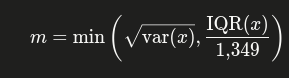

Latimea Silverman: h= 0.003503


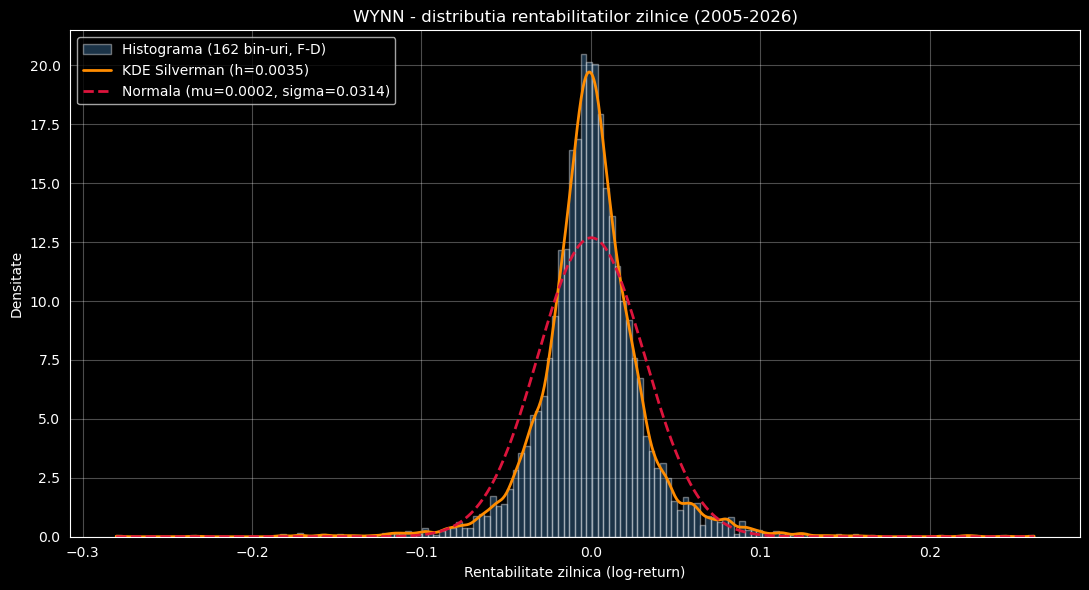

In [12]:
import numpy as np
import statsmodels.nonparametric.kde
import scipy.stats as stats

x_min, x_max = r.min(), r.max()
x_grid = np.linspace(x_min, x_max, 1000)

# normala

mu_hat, sigma_hat = r.mean(), r.std()
pdf_normal = stats.norm.pdf(x_grid, mu_hat, sigma_hat)

#Folosim regula lui Silverman deoarece foloseste min intre sigma si IQR/1.349 care e robust la outliers.

sigma_emp= r.std()
iqr= np.percentile(r,75) - np.percentile(r,25)
m= min(sigma_emp,iqr/1.349)
h_silv=0.9* m/n **(1/5)

print(f"Latimea Silverman: h= {h_silv:.6f}")

# KDE

kde=stats.gaussian_kde(r,bw_method=h_silv/sigma_emp)
pdf_kde= kde(x_grid)

# latimea pt hist (Freedman Diaconis)

h_fd = 2 * iqr * n ** (-1/3)
n_bins = int((x_max - x_min) / h_fd)


fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(r, bins=n_bins, density=True, alpha=0.4, color="steelblue",
        edgecolor="white", label=f"Histograma ({n_bins} bin-uri, F-D)")
ax.plot(x_grid, pdf_kde, color="darkorange", lw=2,
        label=f"KDE Silverman (h={h_silv:.4f})")
ax.plot(x_grid, pdf_normal, color="crimson", lw=2, ls="--",
        label=f"Normala (mu={mu_hat:.4f}, sigma={sigma_hat:.4f})")

ax.set_xlabel("Rentabilitate zilnica (log-return)")
ax.set_ylabel("Densitate")
ax.set_title("WYNN - distributia rentabilitatilor zilnice (2005-2026)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()






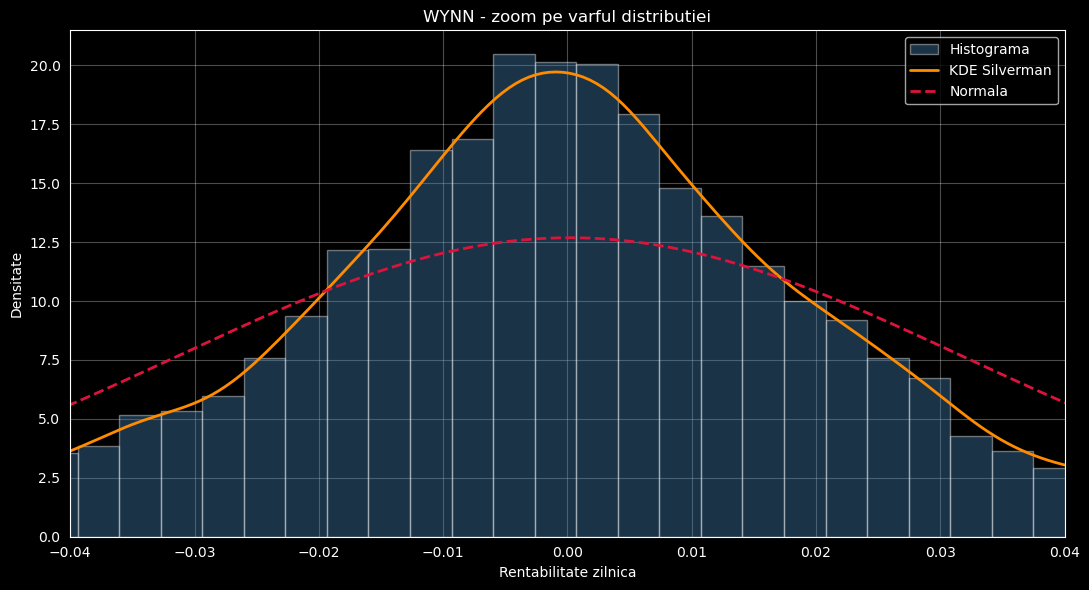

In [15]:
# Zoom pe varful central
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(r, bins=n_bins, density=True, alpha=0.4, color="steelblue",
        edgecolor="white", label="Histograma")
ax.plot(x_grid, pdf_kde, color="darkorange", lw=2, label="KDE Silverman")
ax.plot(x_grid, pdf_normal, color="crimson", lw=2, ls="--", label="Normala")

ax.set_xlim(-0.04, 0.04)
ax.set_xlabel("Rentabilitate zilnica")
ax.set_ylabel("Densitate")
ax.set_title("WYNN - zoom pe varful distributiei")
ax.legend()

plt.tight_layout()
plt.show()

## Comentarii - 1.2

**Bandwidth Silverman.** Regula a ales $h \approx 0{,}00350$, folosind
$\text{IQR}/1{,}349 = 0{,}0217$ in loc de $\sigma_{\text{empiric}} = 0{,}0314$.
Outlierii (COVID 2020, criza 2008) au umflat $\sigma$, dar IQR-ul ramane stabil

**Forma centrala.** KDE-ul are un varf vizibil mai inalt si mai ascutit decat normala
in jurul lui $r = 0$, iar in zonele intermediare ($|r| \in [0{,}01; 0{,}03]$) este
*sub* normala. Aceasta migrare de masa spre centru si spre cozi este rezultatul formei leptocurtice

**Cozile.** Pe graficul global se observa observatii la $-0{,}28$ si $+0{,}26$ care,
sub normala fitata, ar avea probabilitate practic zero. KDE-ul fiind  neparametric
captureaza aceste evenimente; normala nu poate.

 Per total, distributia normala este vizibil un model inadecvat pentru WYNN.
Forma KDE-ului (varf ascutit + cozi grele, aproximativ simetric) sugereaza o
distributie de tip **Student-$t$** cu putine grade de libertate. Vom valida formal
in 1.5 (teste de normalitate) si vom estima distributia adecvata in 1.7 - 1.10.

## 1.3 — Graficul logPDF

Vizualizam $\log \hat{f}(x)$ in loc de $\hat{f}(x)$. Aceasta transformare amplifica
diferentele in cozi (unde valorile densitatii sunt mici) si permite identificarea
vizuala a tipului de coada:

- **normala** — $\log f(x) \propto -(x-\mu)^2$, deci **parabola** in $x$
- **cozi grele** (Student-$t$, NIG) — $\log f(x) \propto -\log|x|$, deci scadere
  mult mai lenta in cozi


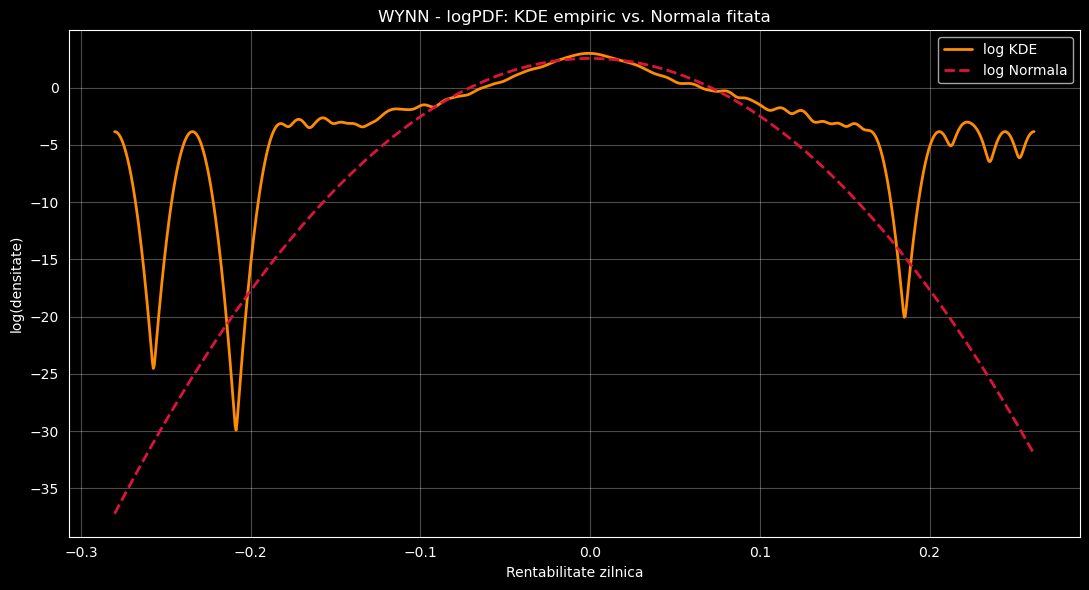

In [18]:
# 1.3 - logPDF
log_kde = np.log(pdf_kde)
log_normal = np.log(pdf_normal)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x_grid, log_kde, color="darkorange", lw=2, label="log KDE")
ax.plot(x_grid, log_normal, color="crimson", lw=2, ls="--", label="log Normala")

ax.set_xlabel("Rentabilitate zilnica")
ax.set_ylabel("log(densitate)")
ax.set_title("WYNN - logPDF: KDE empiric vs. Normala fitata")
ax.legend()
plt.tight_layout()
plt.show()

## Comentarii 1.3

Normala este o parabola perfecta

Cozile WYNN nu sunt patratice, vizual e specific unor distributii cu cozi grele, de genul t student sau NIG

## 1.4 — QQ-plot fata de distributia normala

Compararea cuantilelor empirice ale datelor cu cuantilele teoretice ale
$\mathcal{N}(\hat\mu, \hat\sigma^2)$. Daca datele sunt normale, punctele se aliniaza
pe linia $y = x$.

**Constructie:**
- Sortam datele: $r_{(1)} \leq \ldots \leq r_{(n)}$
- Calculam pozitiile $p_i = (i - 0{,}5)/n$
- Calculam cuantilele teoretice $q_i = \Phi^{-1}(p_i; \hat\mu, \hat\sigma)$
- Plotam $(q_i, r_{(i)})$ + linia de referinta $y = x$

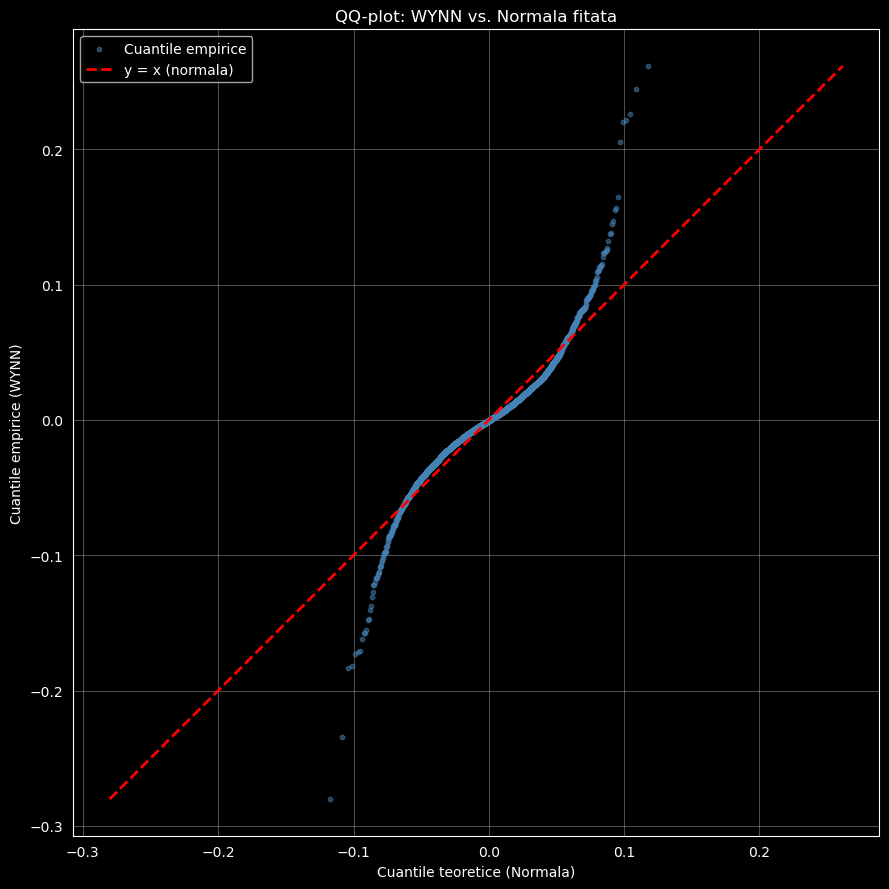

In [19]:

# Sortam datele empirice
r_sorted = np.sort(r)

# Probability plotting positions
p_i = (np.arange(1, n+1) - 0.5) / n

# Cuantilele teoretice ale normalei fitate
q_theoretical = stats.norm.ppf(p_i, loc=mu_hat, scale=sigma_hat)

# Plot
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(q_theoretical, r_sorted, alpha=0.5, s=10, color="steelblue",
           label="Cuantile empirice")


lim_min = min(q_theoretical.min(), r_sorted.min())
lim_max = max(q_theoretical.max(), r_sorted.max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", lw=2, label="y = x (normala)")

ax.set_xlabel("Cuantile teoretice (Normala)")
ax.set_ylabel("Cuantile empirice (WYNN)")
ax.set_title("QQ-plot: WYNN vs. Normala fitata")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Comentarii — 1.4


Observam un S inversat, clasic pt distributii cu cozi groase. In zona centrala (cuantile teoretice in
$[-0{,}05; +0{,}05]$), punctele se aliniaza foarte bine pe linia $y=x$ — corpul
central al distributiei este aproximativ normal(fapt ce l-am observat si eliminand outliers in analiza momentelor centrale la kurtosis). La extreme insa, punctele se
**indeparteaza simetric** de linie: coada stanga sub, coada dreapta deasupra.


**Magnitudinea deviatiei in cozi.**

| | Cuantila teoretica (Normala) | Cuantila empirica (WYNN) |
|---|---|---|
| Cea mai mica observatie | $-0{,}1173$ | $-0{,}2802$ |
| Cea mai mare observatie | $+0{,}1177$ | $+0{,}2615$ |

Observatia cea mai severa ($-28{,}02\%$) este de aproximativ **2,4 ori mai mare**
in valoare absoluta decat cea mai extrema cuantila teoretica posibila sub normala
fituita.

Astfel avem un argument vizual destul de strong ca sa respingem orice ipoteza de normalitate a distributiei pentru modelarea rentabilitatilor WYNN

## 1.5 — Teste formale de normalitate

Aplicam trei teste din familii diferite:

Jarque-Bera care se bazeaza pe momentele superioare (skew+kurt)

Anderson Darling bazat pe CDF, ponderat in cozi. (mi s-a parut interesant sa facem testul asta avand in vedere specificul datelor)

Pentru toate: $H_0$: datele sunt normal distribuite.

In [20]:
# 1.5 - Teste de normalitate
from scipy.stats import jarque_bera, anderson, kstest, norm

# 1. Jarque-Bera
jb_stat, jb_pvalue = jarque_bera(r)
print("Jarque-Bera")
print(f"  Statistica: {jb_stat:.4f}")
print(f"  p-value:    {jb_pvalue:.4e}")
print(f"  Decizie:    respinge H0" if jb_pvalue < 0.05 else "  Decizie: nu respinge H0")
print()

# 2. Anderson-Darling
ad_result = anderson(r, dist="norm")
print("Anderson-Darling")
print(f"  Statistica: {ad_result.statistic:.4f}")
print(f"  Valori critice (semnif. 15%, 10%, 5%, 2.5%, 1%):")
for sig, cv in zip(ad_result.significance_level, ad_result.critical_values):
    flag = "respinge H0" if ad_result.statistic > cv else "OK"
    print(f"    {sig}%: cv={cv:.4f}  [{flag}]")
print()

Jarque-Bera
  Statistica: 15039.2532
  p-value:    0.0000e+00
  Decizie:    respinge H0

Anderson-Darling
  Statistica: 84.0925
  Valori critice (semnif. 15%, 10%, 5%, 2.5%, 1%):
    15.0%: cv=0.5610  [respinge H0]
    10.0%: cv=0.6310  [respinge H0]
    5.0%: cv=0.7520  [respinge H0]
    2.5%: cv=0.8730  [respinge H0]
    1.0%: cv=1.0350  [respinge H0]



/tmp/ipykernel_8513/1207282219.py:13: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(r, dist="norm")


## Comentarii - 1.5


Dupa cum ne asteptam in urma analizei vizuale, testele sunt zdrobitoare, si resping ipoteza nula cu o convingere absoluta.

**Jarque-Bera** detecteaza non-normalitatea prin momentele 3 si 4. Statistica $JB = 15\,039$
este de aproximativ $750$ ori mai mare decat valoarea critica de $20$ a unui $\chi^2_2$
la $\alpha = 0{,}001\%$. $p$-value este atat de mic incat scipy il raporteaza numeric ca
zero. prima oara cand am vazut asta =)

Pentru WYNN, excess kurtosis $= 8{,}20$ singur produce
$JB \approx \frac{n}{24}(g_2-3)^2 = \frac{5363}{24}(8{,}20)^2 \approx 15\,030$ —
aproape exact valoarea observata. Deci **practic toata respingerea vine de la kurtosis-ul
ridicat**, nu de la asimetrie (skewness $= 0{,}16$ contribuie cu doar $\approx 23$ la
statistica totala).

**Anderson-Darling** detecteaza prin diferenta dintre CDF-uri, cu pondere mare la cozi.
Statistica $AD = 84{,}09$ este de $81$ ori mai mare decat valoarea critica la $\alpha = 1\%$
($1{,}035$). Sensibilitatea AD la cozi face ca aceasta valoare extrema sa fie consistenta
cu deviatiile observate vizual in 1.3 si 1.4.




## 1.6 — Rentabilitati saptamanale si lunare. Efectul agregarii temporale

Pentru log-randamente, agregarea este **aditiva**: log-randamentul saptamanal este
suma celor 5 log-randamente zilnice, iar cel lunar este suma a $\sim$22 zilnice.
Aceasta proprietate, combinata cu **Teorema Limita Centrala**, sugereaza ca
distributia ar trebui sa se apropie de normalitate pe masura ce agregam.

In [21]:
# 1.6 - Agregare temporala
from scipy.stats import jarque_bera, anderson

# Agregare prin sumare (log-randamente sunt aditive)
weekly = log_returns.resample("W").sum()
weekly = weekly[weekly != 0]
monthly = log_returns.resample("ME").sum()
monthly = monthly[monthly != 0]

datasets = [("Zilnic", log_returns.values),
            ("Saptamanal", weekly.values),
            ("Lunar", monthly.values)]

# Tabel comparativ statistici descriptive
print("=== Statistici descriptive ===")
print(f"{'Frecv':<12} {'n':>5} {'mean':>10} {'std':>10} {'skew':>8} {'exkurt':>8}")
for label, x in datasets:
    print(f"{label:<12} {len(x):>5} {x.mean():>10.6f} {x.std(ddof=1):>10.6f} "
          f"{stats.skew(x):>8.4f} {stats.kurtosis(x):>8.4f}")

# Tabel teste de normalitate
print("\n=== Teste de normalitate ===")
print(f"{'Frecv':<12} {'JB stat':>12} {'JB p':>12} {'AD stat':>10} {'AD cv 1%':>10}")
for label, x in datasets:
    jb_s, jb_p = jarque_bera(x)
    ad = anderson(x, dist="norm")
    print(f"{label:<12} {jb_s:>12.2f} {jb_p:>12.4e} {ad.statistic:>10.4f} {ad.critical_values[-1]:>10.4f}")

=== Statistici descriptive ===
Frecv            n       mean        std     skew   exkurt
Zilnic        5363   0.000204   0.031447   0.1603   8.1975
Saptamanal    1111   0.000987   0.069321   0.0120   7.0509
Lunar          256   0.004283   0.139771  -0.0084   2.9774

=== Teste de normalitate ===
Frecv             JB stat         JB p    AD stat   AD cv 1%
Zilnic           15039.25   0.0000e+00    84.0925     1.0350
Saptamanal        2301.43   0.0000e+00    14.8319     1.0340
Lunar               94.56   2.9239e-21     1.7218     1.0320


/tmp/ipykernel_8513/1776864708.py:26: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = anderson(x, dist="norm")


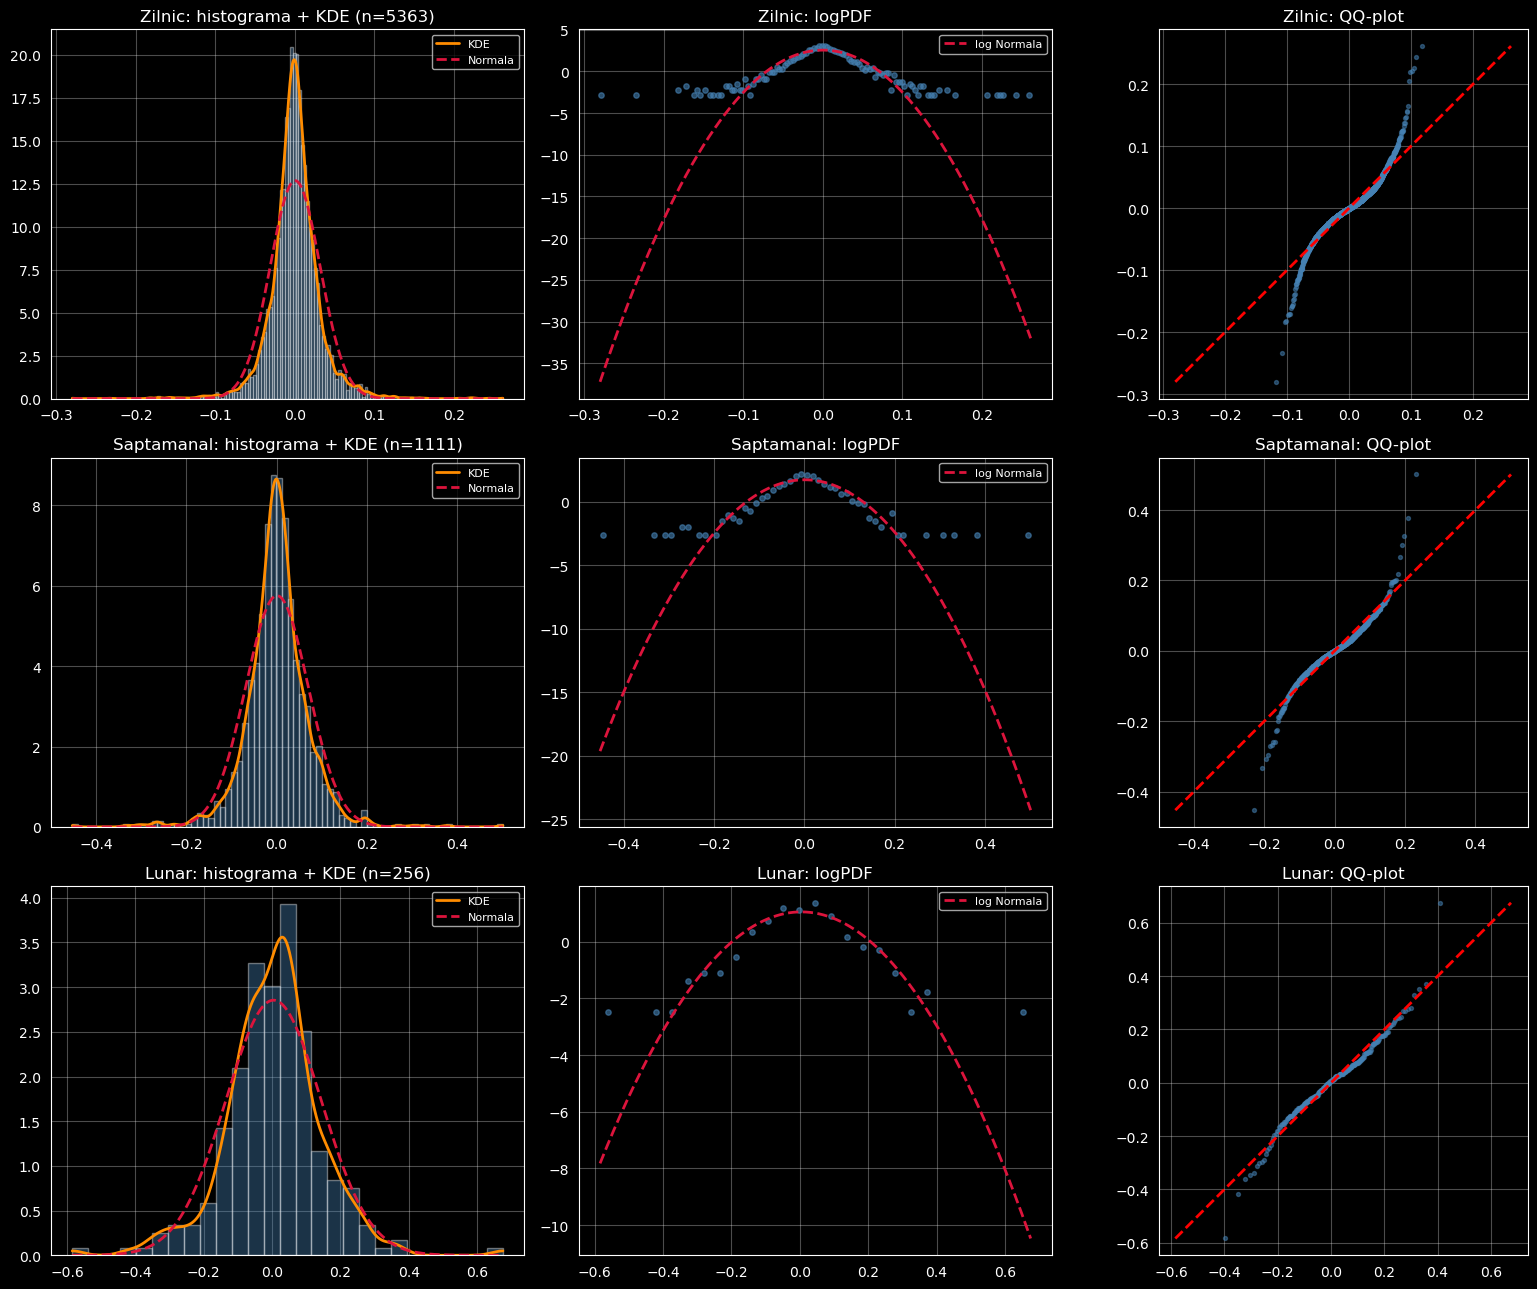

In [22]:
# Graficele
fig, axes = plt.subplots(3, 3, figsize=(16, 13))

for row, (label, r_data) in enumerate(datasets):
    n_d = len(r_data)
    mu, sigma = r_data.mean(), r_data.std(ddof=1)
    iqr_d = np.percentile(r_data, 75) - np.percentile(r_data, 25)
    h_silv = 0.9 * min(sigma, iqr_d/1.349) / n_d**(1/5)

    x_grid = np.linspace(r_data.min(), r_data.max(), 1000)
    pdf_normal = stats.norm.pdf(x_grid, mu, sigma)
    kde = stats.gaussian_kde(r_data, bw_method=h_silv/sigma)
    pdf_kde = kde(x_grid)

    h_fd = 2 * iqr_d * n_d**(-1/3)
    n_bins = max(20, int((r_data.max() - r_data.min()) / h_fd))

    # Col 1: hist + KDE + normal
    ax = axes[row, 0]
    ax.hist(r_data, bins=n_bins, density=True, alpha=0.4, color="steelblue", edgecolor="white")
    ax.plot(x_grid, pdf_kde, color="darkorange", lw=2, label="KDE")
    ax.plot(x_grid, pdf_normal, color="crimson", lw=2, ls="--", label="Normala")
    ax.set_title(f"{label}: histograma + KDE (n={n_d})")
    ax.legend(fontsize=8)

    # Col 2: logPDF
    ax = axes[row, 1]
    counts, edges = np.histogram(r_data, bins=n_bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    nonempty = counts > 0
    ax.scatter(centers[nonempty], np.log(counts[nonempty]), alpha=0.6, s=15, color="steelblue")
    ax.plot(x_grid, np.log(pdf_normal), color="crimson", lw=2, ls="--", label="log Normala")
    ax.set_title(f"{label}: logPDF")
    ax.legend(fontsize=8)

    # Col 3: QQ-plot
    ax = axes[row, 2]
    r_sorted = np.sort(r_data)
    p_i = (np.arange(1, n_d+1) - 0.5) / n_d
    q_th = stats.norm.ppf(p_i, loc=mu, scale=sigma)
    ax.scatter(q_th, r_sorted, alpha=0.5, s=8, color="steelblue")
    lim_min = min(q_th.min(), r_sorted.min())
    lim_max = max(q_th.max(), r_sorted.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", lw=2)
    ax.set_aspect("equal")
    ax.set_title(f"{label}: QQ-plot")

plt.tight_layout()
plt.show()

## Comentarii — 1.6: Efectul agregarii temporale


Tendinta clara rezultata din agregarea temporala releva una dintre cele mai frumoase rezultate din teoria probabilitatilor si anume convergenta catre normalitate (Cental Limit Theorem).


- **Excess kurtosis** scade de la $8{,}20$ (zilnic) la $2{,}98$ (lunar) — o reducere
  de aproximativ $63\%$. Cozile devin mai usoare cu agregarea.
- **Statistica Jarque-Bera** scade de la $15\,039$ la $94{,}6$ — de aproximativ
  $159$ ori mai mica. La frecventa lunara, JB se apropie de un domeniu in care
  testul devine mai discutabil (desi inca respinge formal $H_0$ la $\alpha = 0{,}05$).
- **Statistica Anderson-Darling** scade de la $84{,}1$ la $1{,}72$ — pentru luni,
  $AD = 1{,}72$ este *foarte aproape* de valoarea critica la $\alpha = 1\%$ ($1{,}03$);
  testul respinge inca, dar marginea este mult redusa.


**Vizual:**

- *Zilnic:* "S" inversat dramatic in QQ-plot, varf KDE ascutit, cozi cu plafon
  orizontal in logPDF.
- *Saptamanal:* QQ-plot inca prezinta deviatii in cozi, dar moderate; KDE-ul
  incepe sa se apropie de forma normala.
- *Lunar:* QQ-plot aproape liniar pe toata gama; KDE practic suprapus cu normala
  in centru; logPDF formeaza o parabola aproape perfecta.


Astfel implicatiile in cazul nostru sunt urmatoarele:

1. Modelele cu cozi grele (Student-$t$, NIG) sunt **strict necesare** la frecventa
   zilnica. Pentru frecventa lunara, normala devine o aproximare *rezonabila* (desi
   inca formal respinsa in cazul nostru).
2.  Pentru risc management pe orizont scurt (1 zi, VaR
   intraday), ipoteza de normalitate este periculos de inadecvata. Pentru orizonturi
   mai lungi (lunare, anuale), aproximarea Gaussiana devine mai acceptabila.





